# DINOv2 Feature Extraction and t-SNE Visualization
Reproduces semantic separability visualization similar to "Latent Diffusion Model Without Variational Autoencoder" paper

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tqdm import tqdm
import random
from typing import List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

In [2]:
class Config:
    # Model settings
    DINO_MODEL = 'dinov2_vitb14'  # Options: dinov2_vits14, dinov2_vitb14, dinov2_vitl14, dinov2_vitg14
    
    # Dataset settings
    NUM_CLASSES = 10
    SAMPLES_PER_CLASS = 100
    IMAGE_SIZE = 518  # DINOv2 recommended size (multiple of 14)
    
    # t-SNE settings
    TSNE_PERPLEXITY = 30
    TSNE_N_ITER = 1000
    TSNE_RANDOM_STATE = 42
    
    # Visualization settings
    FIGURE_SIZE = (16, 6)
    POINT_SIZE = 50
    POINT_ALPHA = 0.7
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Random seed
    SEED = 42

In [3]:
SELECTED_CLASSES = {
    0: ('tench', 0),
    1: ('goldfish', 1),
    2: ('great white shark', 2),
    3: ('tiger', 292),
    4: ('ladybug', 301),
    5: ('golden retriever', 207),
    6: ('sports car', 817),
    7: ('airliner', 404),
    8: ('church', 497),
    9: ('orange', 950),
}

# More visually distinct classes
DIVERSE_CLASSES = {
    0: ('golden retriever', 207),
    1: ('tabby cat', 281),
    2: ('sports car', 817),
    3: ('airliner', 404),
    4: ('sunflower', 985),
    5: ('pizza', 963),
    6: ('penguin', 145),
    7: ('guitar', 546),
    8: ('church', 497),
    9: ('butterfly', 323),
}

In [4]:
def set_seed(seed: int):
    """Set random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

### ImageNetLoader

In [5]:
class ImageNetLoader:
    """Handles loading ImageNet or ImageNet-1k from various sources"""
    
    def __init__(self, config: Config):
        self.config = config
        self.transform = self._get_transform()
    
    def _get_transform(self):
        """Get preprocessing transform for DINOv2"""
        return transforms.Compose([
            transforms.Resize(self.config.IMAGE_SIZE, interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.CenterCrop(self.config.IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
        ])
    
    def load_from_huggingface(self, class_indices: List[int], samples_per_class: int):
        """
        Load ImageNet from HuggingFace datasets
        Note: Requires authentication for ImageNet-1k
        """
        try:
            from datasets import load_dataset
            
            print("Loading ImageNet from HuggingFace...")
            print("Note: This requires authentication. Run 'huggingface-cli login' first.")
            
            # Load validation split (smaller)
            dataset = load_dataset(
                'imagenet-1k', 
                split='validation',
                trust_remote_code=True
            )
            
            images = []
            labels = []
            
            for class_idx, imagenet_idx in enumerate(class_indices):
                # Filter samples for this class
                class_samples = [
                    i for i, label in enumerate(dataset['label']) 
                    if label == imagenet_idx
                ][:samples_per_class]
                
                for sample_idx in tqdm(class_samples, desc=f"Loading class {class_idx}"):
                    img = dataset[sample_idx]['image'].convert('RGB')
                    images.append(self.transform(img))
                    labels.append(class_idx)
            
            return torch.stack(images), torch.tensor(labels)
            
        except Exception as e:
            print(f"Error loading from HuggingFace: {e}")
            return None, None
    
    def load_from_folder(self, root_path: str, class_folders: List[str], samples_per_class: int):
        """
        Load from local ImageNet folder structure
        Expected structure: root_path/class_folder/images.JPEG
        """
        from torchvision.datasets import ImageFolder
        import os
        
        images = []
        labels = []
        
        for class_idx, folder_name in enumerate(class_folders):
            class_path = os.path.join(root_path, folder_name)
            if not os.path.exists(class_path):
                print(f"Warning: {class_path} not found")
                continue
            
            image_files = [
                f for f in os.listdir(class_path) 
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ][:samples_per_class]
            
            for img_file in tqdm(image_files, desc=f"Loading {folder_name}"):
                from PIL import Image
                img_path = os.path.join(class_path, img_file)
                img = Image.open(img_path).convert('RGB')
                images.append(self.transform(img))
                labels.append(class_idx)
        
        return torch.stack(images), torch.tensor(labels)
    
    def load_synthetic_demo(self, num_classes: int, samples_per_class: int):
        """
        Create synthetic demo data for testing without ImageNet
        Uses CIFAR-10 as a substitute
        """
        from torchvision.datasets import CIFAR10
        
        print("Loading CIFAR-10 as demo dataset...")
        
        # Use CIFAR-10 transform
        transform = transforms.Compose([
            transforms.Resize(self.config.IMAGE_SIZE, interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
        ])
        
        dataset = CIFAR10(root='./data', train=False, download=True, transform=transform)
        
        images = []
        labels = []
        
        # CIFAR-10 class names
        cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck']
        
        print("Choosing samples from dataset")


        # for class_idx in tqdm(range(min(num_classes, 10))):
        #     class_indices = [i for i, (_, label) in enumerate(dataset) if label == class_idx]
        #     selected = random.sample(class_indices, min(samples_per_class, len(class_indices)))
        #     for idx in selected:
        #         img, _ = dataset[idx]
        #         images.append(img)
        #         labels.append(class_idx)
        
        class_indices = {i: [] for i in range(min(num_classes, 10))}

        for idx, (_, label) in enumerate(tqdm(dataset, desc="Collecting indices")):
            if label < len(class_indices):
                class_indices[label].append(idx)


        for class_idx in tqdm(range(min(num_classes, 10)), desc="Sampling images"):
            indices = class_indices[class_idx]
            if indices:
                selected = random.sample(indices, min(samples_per_class, len(indices)))
                for idx in selected:
                    img, label = dataset[idx]
                    images.append(img)
                    labels.append(label)

        class_names = {i: (cifar_classes[i], i) for i in range(min(num_classes, 10))}
        
        return torch.stack(images), torch.tensor(labels), class_names




### DINOv2 Feature Extractor


In [6]:
class DINOv2FeatureExtractor:
    """Extracts features using DINOv2 model"""
    
    def __init__(self, model_name: str = 'dinov2_vitb14', device: torch.device = None):
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model_name = model_name
        self.model = self._load_model()
        
    def _load_model(self):
        """Load DINOv2 model from torch hub"""
        print(f"Loading {self.model_name}...")
        model = torch.hub.load('facebookresearch/dinov2', self.model_name)
        model = model.to(self.device)
        model.eval()
        print(f"Model loaded on {self.device}")
        return model
    
    def extract_features(self, images: torch.Tensor, batch_size: int = 32) -> np.ndarray:
        """
        Extract CLS token features from images
        
        Args:
            images: Tensor of shape (N, C, H, W)
            batch_size: Batch size for processing
            
        Returns:
            features: numpy array of shape (N, feature_dim)
        """
        features_list = []
        
        with torch.no_grad():
            for i in tqdm(range(0, len(images), batch_size), desc="Extracting features"):
                batch = images[i:i+batch_size].to(self.device)
                
                # Get CLS token features
                features = self.model(batch)
                features_list.append(features.cpu().numpy())
        
        return np.concatenate(features_list, axis=0)
    
    def extract_patch_features(self, images: torch.Tensor, batch_size: int = 32) -> np.ndarray:
        """
        Extract patch token features (for spatial visualization)
        
        Returns:
            features: numpy array of shape (N, num_patches, feature_dim)
        """
        features_list = []
        
        with torch.no_grad():
            for i in tqdm(range(0, len(images), batch_size), desc="Extracting patch features"):
                batch = images[i:i+batch_size].to(self.device)
                
                # Get all features including patch tokens
                features = self.model.forward_features(batch)
                patch_tokens = features['x_norm_patchtokens']
                features_list.append(patch_tokens.cpu().numpy())
        
        return np.concatenate(features_list, axis=0)

### DINOv3 Feature Extractor


In [ ]:
# from transformers import AutoModel, AutoImageProcessor


# class DINOv3FeatureExtractor:
#     """Extracts features using DINOv3 (Transformers version)"""

#     def __init__(
#         self,
#         model_name: str = "facebook/dinov3-vitb16-pretrain",
#         device: torch.device | None = None,
#     ):
#         self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
#         self.model_name = model_name

#         self.processor = AutoImageProcessor.from_pretrained(model_name)
#         self.model = self._load_model()

#     def _load_model(self):
#         """Load DINOv3 model from Hugging Face"""
#         print(f"Loading {self.model_name}...")
#         model = AutoModel.from_pretrained(self.model_name)
#         model.to(self.device)
#         model.eval()
#         print(f"Model loaded on {self.device}")
#         return model

#     def _preprocess(self, images: torch.Tensor) -> torch.Tensor:
#         """
#         Preprocess images for DINOv3

#         Args:
#             images: Tensor (N, C, H, W) in range [0, 1] or [0, 255]

#         Returns:
#             pixel_values: Tensor (N, 3, H, W)
#         """
#         # Convert to list of images expected by HF processor
#         images = [img for img in images]
#         inputs = self.processor(images=images, return_tensors="pt")
#         return inputs["pixel_values"]

#     def extract_features(self, images: torch.Tensor, batch_size: int = 32) -> np.ndarray:
#         """
#         Extract CLS token features

#         Args:
#             images: Tensor (N, C, H, W)
#             batch_size: Batch size

#         Returns:
#             features: (N, hidden_dim)
#         """
#         features_list = []

#         with torch.no_grad():
#             for i in tqdm(range(0, len(images), batch_size), desc="Extracting CLS features"):
#                 batch = images[i : i + batch_size]
#                 pixel_values = self._preprocess(batch).to(self.device)


### t-SNE Visualization

In [7]:
class FeatureVisualizer:
    """Handles t-SNE computation and visualization"""
    
    def __init__(self, config: Config):
        self.config = config
        
    def compute_tsne(self, features: np.ndarray) -> np.ndarray:
        """
        Apply t-SNE dimensionality reduction
        
        Args:
            features: numpy array of shape (N, feature_dim)
            
        Returns:
            embedded: numpy array of shape (N, 2)
        """
        print(f"Computing t-SNE on {features.shape[0]} samples with {features.shape[1]} dimensions...")
        
        tsne = TSNE(
            n_components=2,
            perplexity=min(self.config.TSNE_PERPLEXITY, features.shape[0] - 1),
            n_iter=self.config.TSNE_N_ITER,
            random_state=self.config.TSNE_RANDOM_STATE,
            verbose=1
        )
        
        embedded = tsne.fit_transform(features)
        print("t-SNE completed!")
        
        return embedded
    
    def plot_features_and_tsne(
        self,
        features: np.ndarray,
        tsne_embedded: np.ndarray,
        labels: np.ndarray,
        class_names: dict,
        save_path: Optional[str] = None
    ):
        """
        Create side-by-side visualization of feature space and t-SNE
        Similar to the paper figure
        """
        fig, axes = plt.subplots(1, 2, figsize=self.config.FIGURE_SIZE)
        
        # Get unique labels and create color map
        unique_labels = np.unique(labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
        
        # Left plot: PCA of features (2D projection)
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        features_pca = pca.fit_transform(features)
        
        ax1 = axes[0]
        for i, label in enumerate(unique_labels):
            mask = labels == label
            class_name = class_names.get(label, (f'Class {label}', label))[0]
            ax1.scatter(
                features_pca[mask, 0],
                features_pca[mask, 1],
                c=[colors[i]],
                label=class_name,
                s=self.config.POINT_SIZE,
                alpha=self.config.POINT_ALPHA,
                edgecolors='white',
                linewidths=0.5
            )
        
        ax1.set_title('DINOv2 Features (PCA)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('PC1', fontsize=12)
        ax1.set_ylabel('PC2', fontsize=12)
        ax1.grid(True, alpha=0.3)
        
        # Right plot: t-SNE embedding
        ax2 = axes[1]
        for i, label in enumerate(unique_labels):
            mask = labels == label
            class_name = class_names.get(label, (f'Class {label}', label))[0]
            ax2.scatter(
                tsne_embedded[mask, 0],
                tsne_embedded[mask, 1],
                c=[colors[i]],
                label=class_name,
                s=self.config.POINT_SIZE,
                alpha=self.config.POINT_ALPHA,
                edgecolors='white',
                linewidths=0.5
            )
        
        ax2.set_title('t-SNE Visualization', fontsize=14, fontweight='bold')
        ax2.set_xlabel('t-SNE 1', fontsize=12)
        ax2.set_ylabel('t-SNE 2', fontsize=12)
        ax2.grid(True, alpha=0.3)
        
        # Add legend
        ax2.legend(
            bbox_to_anchor=(1.05, 1),
            loc='upper left',
            fontsize=10,
            framealpha=0.9
        )
        
        plt.suptitle(
            'DINOv2 Feature Space Semantic Separability',
            fontsize=16,
            fontweight='bold',
            y=1.02
        )
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"Figure saved to {save_path}")
        
        plt.show()
        
        return fig
    
    def plot_tsne_only(
        self,
        tsne_embedded: np.ndarray,
        labels: np.ndarray,
        class_names: dict,
        save_path: Optional[str] = None
    ):
        """Create single t-SNE plot"""
        fig, ax = plt.subplots(figsize=(10, 10))
        
        unique_labels = np.unique(labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
        
        for i, label in enumerate(unique_labels):
            mask = labels == label
            class_name = class_names.get(label, (f'Class {label}', label))[0]
            ax.scatter(
                tsne_embedded[mask, 0],
                tsne_embedded[mask, 1],
                c=[colors[i]],
                label=class_name,
                s=self.config.POINT_SIZE * 1.5,
                alpha=self.config.POINT_ALPHA,
                edgecolors='white',
                linewidths=0.5
            )
        
        ax.set_title('DINOv2 Features - t-SNE Visualization', fontsize=16, fontweight='bold')
        ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
        ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
        ax.legend(fontsize=11, loc='best', framealpha=0.9)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"Figure saved to {save_path}")
        
        plt.show()
        
        return fig

### Pipeline

In [10]:
def run_visualization(
    use_demo_data: bool = True,
    imagenet_path: Optional[str] = None,
    num_classes: int = 10,
    samples_per_class: int = 100,
    save_path: str = 'dinov2_tsne_visualization.png'
):
    """
    Main function to run the complete visualization pipeline
    
    Args:
        use_demo_data: If True, use CIFAR-10 as demo. If False, try to load ImageNet
        imagenet_path: Path to local ImageNet folder (optional)
        num_classes: Number of classes to visualize
        samples_per_class: Number of samples per class
        save_path: Path to save the output figure
    """
    # Initialize configuration
    config = Config()
    config.NUM_CLASSES = num_classes
    config.SAMPLES_PER_CLASS = samples_per_class
    # config.DINO_MODEL = "facebook/dinov3-vitb16-pretrain"
    # Set random seed
    set_seed(config.SEED)
    
    print("="*60)
    print("DINOv2 Feature Visualization Pipeline")
    print("="*60)
    print(f"Device: {config.DEVICE}")
    print(f"Model: {config.DINO_MODEL}")
    print(f"Classes: {num_classes}")
    print(f"Samples per class: {samples_per_class}")
    print("="*60)
    
    # Load dataset
    loader = ImageNetLoader(config)
    
    if use_demo_data:
        images, labels, class_names = loader.load_synthetic_demo(
            num_classes, samples_per_class
        )
    elif imagenet_path:
        # Load from local folder
        class_folders = list(DIVERSE_CLASSES.values())[:num_classes]
        folder_names = [f"n{idx:08d}" for _, idx in class_folders]  # ImageNet folder format
        images, labels = loader.load_from_folder(
            imagenet_path, folder_names, samples_per_class
        )
        class_names = {i: v for i, v in enumerate(list(DIVERSE_CLASSES.values())[:num_classes])}
    else:
        # Try HuggingFace
        class_indices = [idx for _, idx in list(DIVERSE_CLASSES.values())[:num_classes]]
        images, labels = loader.load_from_huggingface(class_indices, samples_per_class)
        class_names = {i: v for i, v in enumerate(list(DIVERSE_CLASSES.values())[:num_classes])}
    
    if images is None:
        print("Failed to load dataset. Using demo data instead.")
        images, labels, class_names = loader.load_synthetic_demo(
            num_classes, samples_per_class
        )
    
    print(f"\nDataset loaded: {len(images)} images")
    print(f"Classes: {list(class_names.values())}")
    
    # Extract features using DINOv2
    extractor = DINOv2FeatureExtractor(config.DINO_MODEL, config.DEVICE)
    features = extractor.extract_features(images, batch_size=32)
    print(f"Features shape: {features.shape}")
    
    # Compute t-SNE
    visualizer = FeatureVisualizer(config)
    tsne_embedded = visualizer.compute_tsne(features)
    
    # Create visualization
    labels_np = labels.numpy()
    
    # Combined plot (PCA + t-SNE)
    visualizer.plot_features_and_tsne(
        features, tsne_embedded, labels_np, class_names,
        save_path=save_path
    )
    
    # t-SNE only plot
    tsne_save_path = save_path.replace('.png', '_tsne_only.png')
    visualizer.plot_tsne_only(
        tsne_embedded, labels_np, class_names,
        save_path=tsne_save_path
    )
    
    print("\nVisualization complete!")
    
    return features, tsne_embedded, labels_np, class_names

In [ ]:
features, tsne, labels, class_names = run_visualization()

DINOv2 Feature Visualization Pipeline
Device: cpu
Model: dinov2_vitb14
Classes: 10
Samples per class: 100
Loading CIFAR-10 as demo dataset...
Files already downloaded and verified
Choosing samples from dataset


Sampling images: 100%|██████████| 10/10 [00:02<00:00,  3.96it/s]



Dataset loaded: 1000 images
Classes: [('airplane', 0), ('automobile', 1), ('bird', 2), ('cat', 3), ('deer', 4), ('dog', 5), ('frog', 6), ('horse', 7), ('ship', 8), ('truck', 9)]
Loading dinov2_vitb14...


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /Users/niyazgarifzyanov/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /Users/niyazgarifzyanov/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth
100%|██████████| 330M/330M [00:50<00:00, 6.89MB/s] 


Model loaded on cpu


Extracting features:   9%|▉         | 3/32 [01:15<11:46, 24.38s/it]

DINOv2 Feature Visualization Pipeline
Device: cuda
Model: dinov2_vitb14
Classes: 10
Samples per class: 100
Loading CIFAR-10 as demo dataset...
Choosing samples from dataset


Sampling images: 100%|██████████| 10/10 [00:06<00:00,  1.65it/s]



Dataset loaded: 1000 images
Classes: [('airplane', 0), ('automobile', 1), ('bird', 2), ('cat', 3), ('deer', 4), ('dog', 5), ('frog', 6), ('horse', 7), ('ship', 8), ('truck', 9)]
Loading dinov2_vitb14...


Using cache found in /home/garifzjanovni/.cache/torch/hub/facebookresearch_dinov2_main


Model loaded on cuda


Extracting features: 100%|██████████| 32/32 [00:49<00:00,  1.53s/it]


Features shape: (1000, 768)
Computing t-SNE on 1000 samples with 768 dimensions...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.001s...
[t-SNE] Computed neighbors for 1000 samples in 0.184s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 17.250721
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.468056
[t-SNE] KL divergence after 1000 iterations: 0.656187
t-SNE completed!
Figure saved to dinov2_tsne_visualization.png


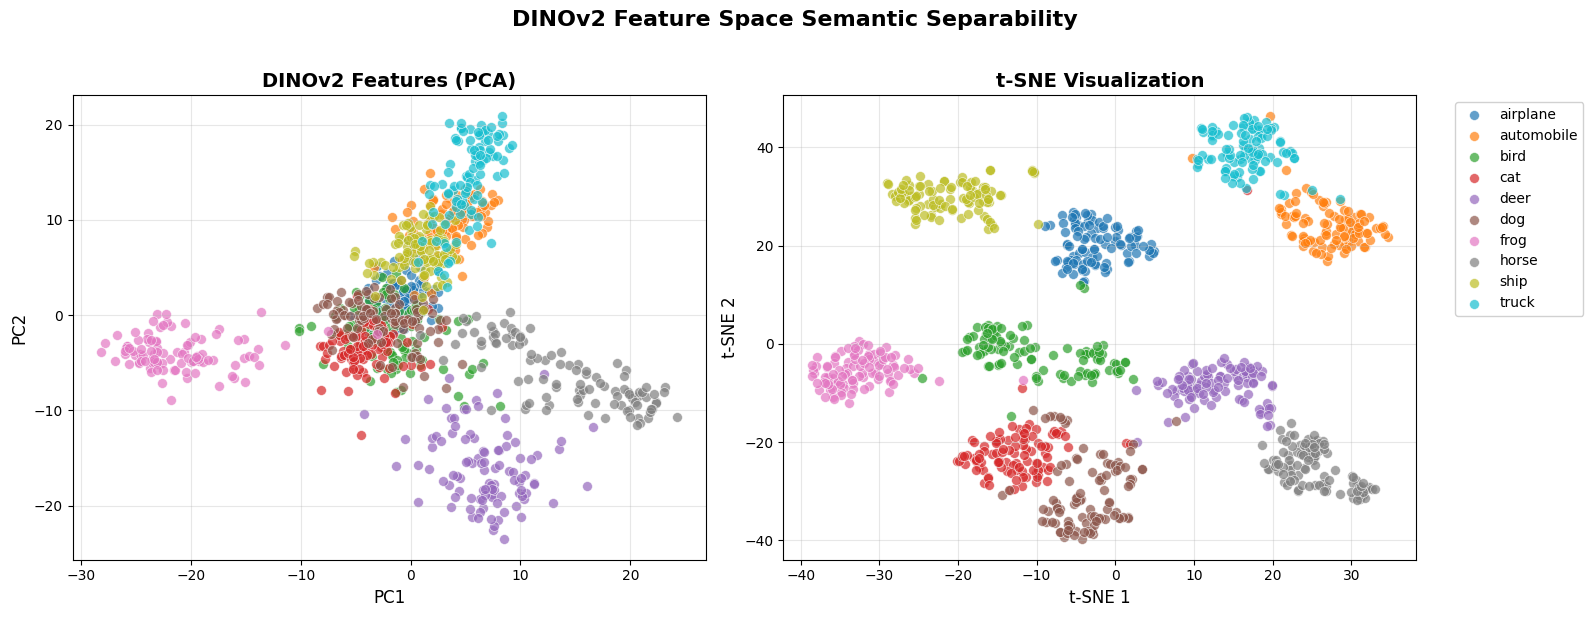

Figure saved to dinov2_tsne_visualization_tsne_only.png


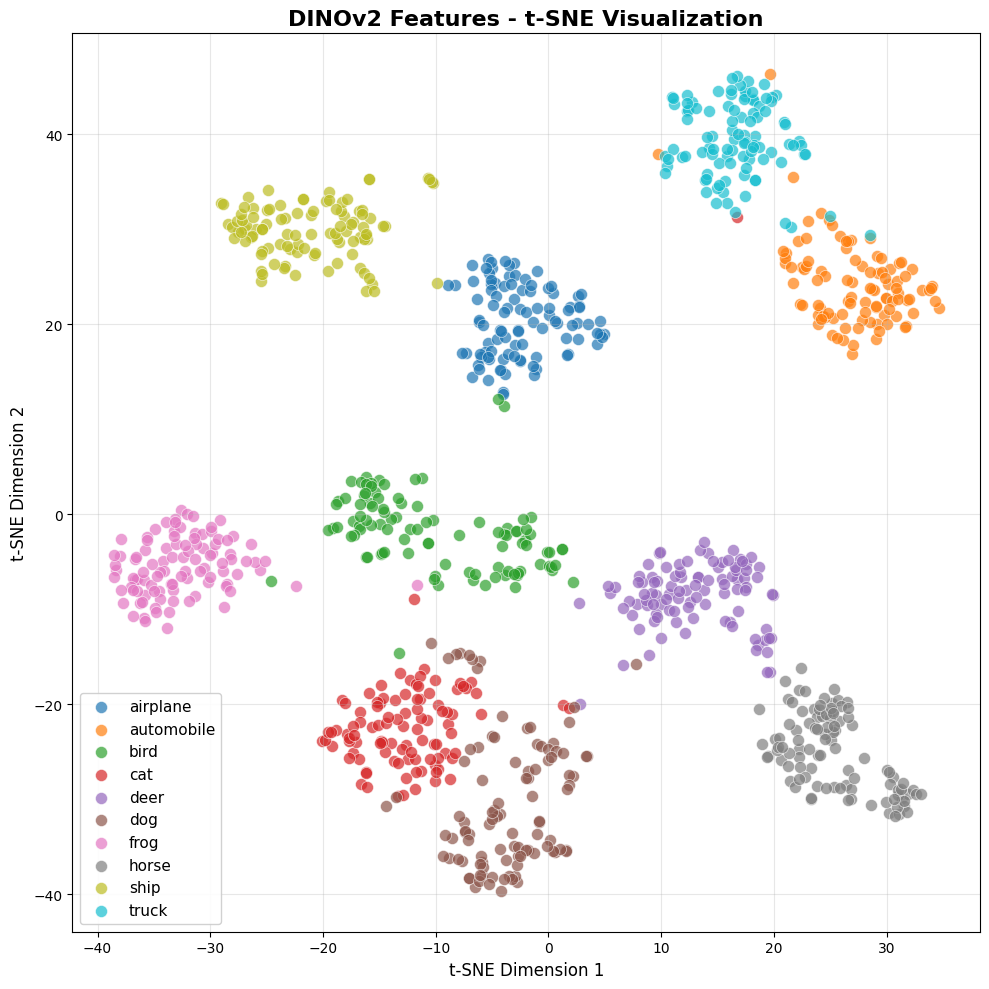


Visualization complete!


In [10]:
features, tsne, labels, class_names = run_visualization()